# Node classification sweep performance 

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [1]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [3]:
import wandb
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: francesca-drummer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [29]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs

In [6]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [12]:
GNN_sweep = "l0jetvrz"
InterScale_sweep = "yqvyut7l"
PCATrans_sweep = "8govw06t"

## Graph Classification performance

In [10]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial']

Q: Why does PCATrans not have test_f1 scores?

In [13]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [18]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,nc6wcxh4,melton25_clas_node_44_GCN_,44,finished,0.5,150,None,583.736024,255145,0.410172,None,0.074074,0.577701,0.187302,0.483192,0.000000,0.219942,0.0,0.120466
1,n72wxcou,melton25_clas_node_44_GCN_,43,finished,0.5,150,None,610.241567,255145,0.345615,None,0.074074,0.741093,0.150794,0.000000,0.222222,0.160729,0.0,0.000000
2,qrvo7c6z,melton25_clas_node_44_GCN_,42,finished,0.5,150,None,623.258038,255145,0.229102,None,0.211111,0.552431,0.111111,0.012950,0.111111,0.143627,0.0,0.020202
3,ltgzyu44,melton25_clas_node_44_GCN_,41,finished,0.5,150,None,587.714794,255145,0.158501,None,0.111111,0.392892,0.055556,0.008230,0.055556,0.165252,0.0,0.055931
4,o6zttv7w,melton25_clas_node_44_GCN_,40,finished,0.5,150,None,594.628172,255145,0.357124,None,0.111111,0.492742,0.211111,0.474357,0.111111,0.191293,0.0,0.029440


In [19]:
PCATrans_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.00,0,0.577588,0.008156,0.667466,0.024096,0.640212,0.021847
1,0.00,60,0.594320,0.013006,0.666606,0.017713,0.644392,0.016974
2,0.00,110,0.586678,0.016286,0.664615,0.017622,0.637815,0.015616
3,0.00,150,0.586678,0.016286,0.664615,0.017622,0.637815,0.015616
4,0.10,0,0.096939,0.115481,0.014815,0.033127,0.149527,0.194294
5,0.10,60,0.145628,0.164657,0.029630,0.040572,0.262381,0.337292
6,0.10,110,0.145628,0.164657,0.029630,0.040572,0.262381,0.337292
7,0.10,150,0.145628,0.164657,0.029630,0.040572,0.262381,0.337292
8,0.25,0,0.200026,0.090773,0.072581,0.100241,0.438530,0.182190
9,0.25,60,0.198251,0.081665,0.066843,0.091974,0.421540,0.121940


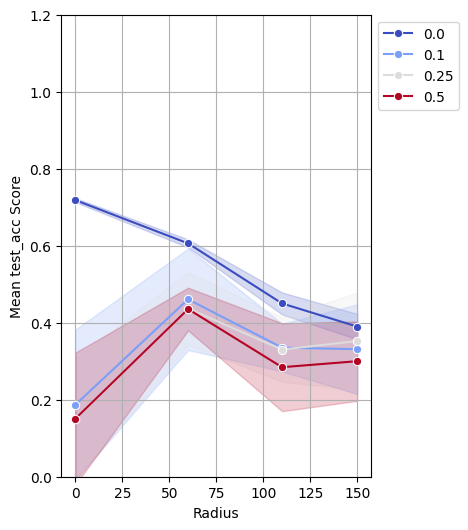

In [14]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

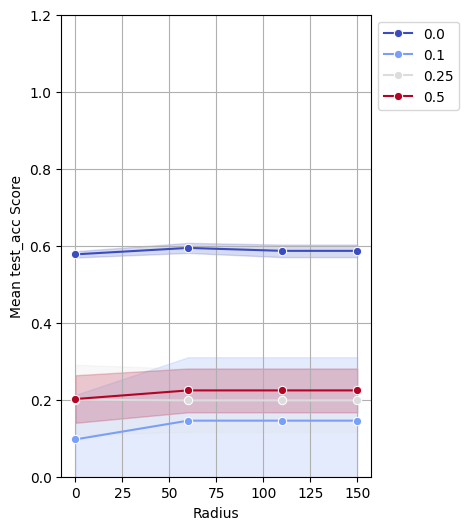

In [15]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

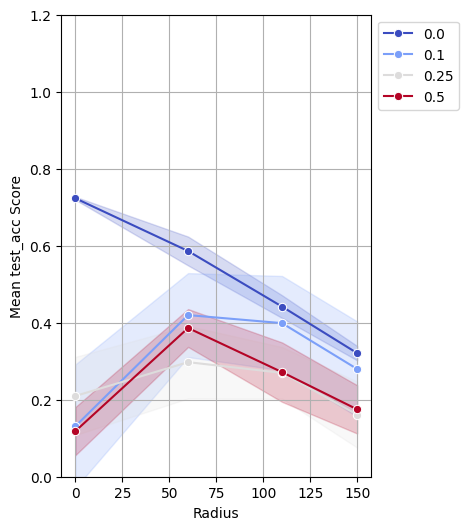

In [16]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

In [26]:
wandb_evals = [GNN_wandb, PCATrans_wandb, InterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

             model                      class      mean       std  n_seeds
0              GCN       test_f1_class_Acinar  0.528654  0.084491        5
1              GCN        test_f1_class_Alpha  0.107407  0.103439        5
2              GCN         test_f1_class_Beta  0.166667  0.055556        5
3              GCN       test_f1_class_Ductal  0.532613  0.085451        5
4              GCN    test_f1_class_Endocrine  0.044444  0.060858        5
5              GCN  test_f1_class_Endothelial  0.034815  0.056389        5
6              GCN       test_f1_class_Immune  0.146862  0.142870        5
7              GCN         test_f1_class_Mast  0.000000  0.000000        5
8       InterScale       test_f1_class_Acinar  0.413481  0.133942        5
9       InterScale        test_f1_class_Alpha  0.092593  0.085867        5
10      InterScale         test_f1_class_Beta  0.148889  0.064278        5
11      InterScale       test_f1_class_Ductal  0.327959  0.122502        5
12      InterScale    tes

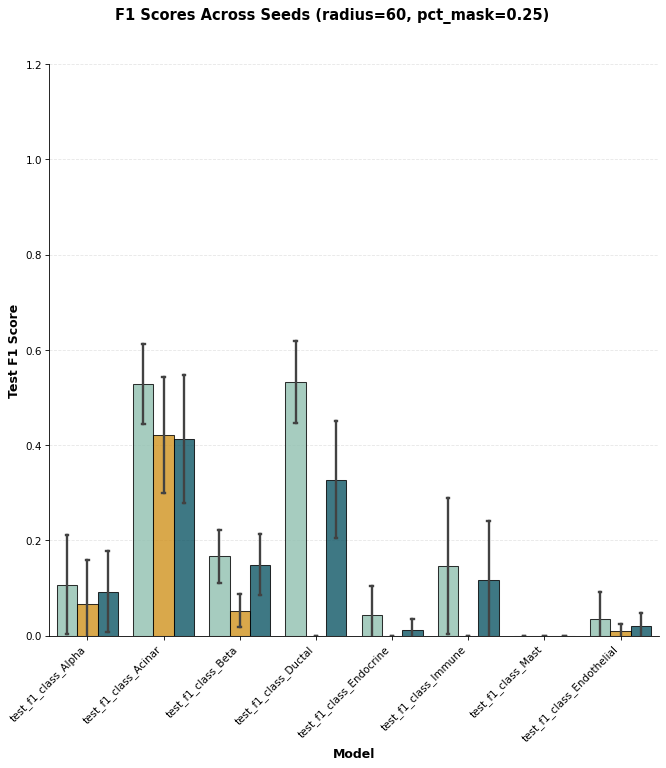

In [35]:

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=60,
    pct_mask_nodes=0.25,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/node_class/f1_comparison_models_radius'
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

## Class robustness

In [42]:
def plot_class_f1_robustness(wandb_evaluations, class_idx, pct_mask_nodes=None, BASE_DIR_REPO=None, y_max='auto',
                              save_path=None, figsize=(8, 6)):
    """
    Plot class-specific F1 score robustness across radius, comparing multiple models.
    
    Parameters:
    -----------
    wandb_evaluations : list of Wandb_evaluation
        List of Wandb_evaluation instances, one per model
    class_idx : str or int
        Class index to plot F1 for
    pct_mask_nodes : float or int, optional
        Percentage of masked nodes to filter by (if None, uses all data)
    BASE_DIR_REPO : str, optional
        Base directory for config files
    save_path : str, optional
        Path to save the figure
    figsize : tuple, optional
        Figure size (default: (8, 6))
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    stats_df : pd.DataFrame with mean and std for each radius and model
    """
    general_config, model_palette = set_plot_configs(BASE_DIR_REPO)
    
    all_data = []
    
    for wandb_eval in wandb_evaluations:
        df = wandb_eval.df.copy()
        model_name = wandb_eval.model
        
        # Apply filter if specified
        if pct_mask_nodes is not None:
            df = df[df['pct_mask_nodes'] == pct_mask_nodes]
        
        if df.empty:
            print(f"Warning: No data for {model_name} with specified filters")
            continue
        
        # Get F1 column for specified class
        f1_col = f'test_f1_class_{class_idx}'
        
        if f1_col not in df.columns:
            print(f"Warning: {f1_col} not found for {model_name}")
            continue
        
        plot_df = df[['radius', 'seed', f1_col]].copy() if 'seed' in df.columns else df[['radius', f1_col]].copy()
        plot_df = plot_df.rename(columns={f1_col: 'f1_score'})
        plot_df['model'] = model_name
        all_data.append(plot_df)
    
    if not all_data:
        raise ValueError("No valid data found for any model")
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Calculate statistics
    stats_df = combined_df.groupby(['model', 'radius'])['f1_score'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.lineplot(
        data=combined_df,
        x='radius',
        y='f1_score',
        hue='model',
        marker='o',
        errorbar='sd',
        palette=model_palette,
        ax=ax
    )
    
    ax.set_xlabel('Radius', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    
    title = f'Class {class_idx} F1 Robustness Across Models'
    if pct_mask_nodes is not None:
        title += f' (pct_mask={pct_mask_nodes})'
    
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Set y-axis limits
    if y_max == 'auto':
        y_max_val = combined_df['f1_score'].max() + 0.2
    else:
        y_max_val = y_max
    ax.set_ylim(0, y_max_val)
    
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1, 1), framealpha=0.9)
    
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(
            os.path.join(save_path, f'f1_robustness_class_{class_idx}_{pct_mask_nodes}.jpg'),
            dpi=300, bbox_inches='tight'
        )
    
    plt.show()
    
    print("\nStatistics Summary:")
    print(stats_df.to_string(index=False))
    
    return fig, ax, stats_df

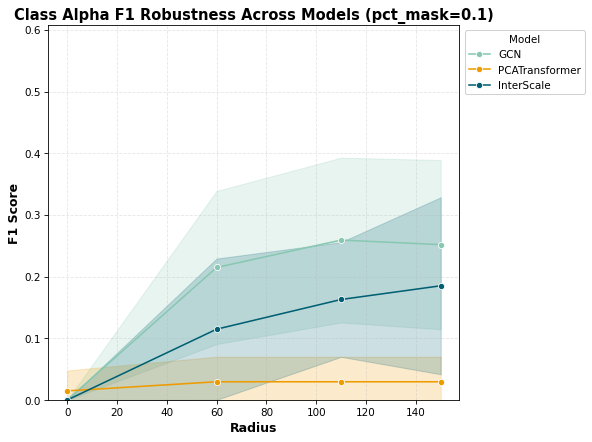


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.214815 0.123950        5
           GCN     110 0.259259 0.133539        5
           GCN     150 0.251852 0.137087        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.114815 0.114456        5
    InterScale     110 0.162963 0.092962        5
    InterScale     150 0.185185 0.143444        5
PCATransformer       0 0.014815 0.033127        5
PCATransformer      60 0.029630 0.040572        5
PCATransformer     110 0.029630 0.040572        5
PCATransformer     150 0.029630 0.040572        5


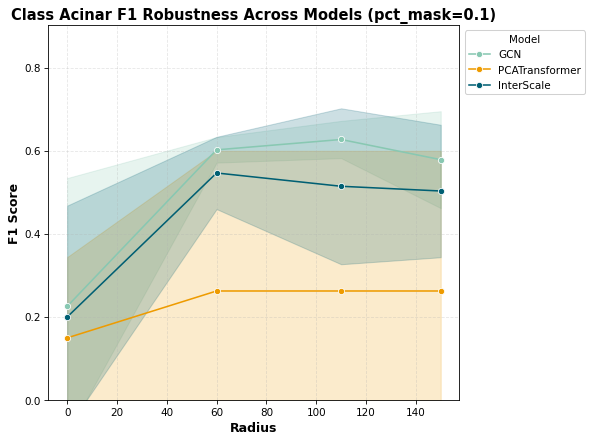


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.225348 0.308657        5
           GCN      60 0.602019 0.030702        5
           GCN     110 0.626900 0.044740        5
           GCN     150 0.578364 0.116595        5
    InterScale       0 0.199701 0.268023        5
    InterScale      60 0.546362 0.086946        5
    InterScale     110 0.514346 0.187607        5
    InterScale     150 0.502964 0.159356        5
PCATransformer       0 0.149527 0.194294        5
PCATransformer      60 0.262381 0.337292        5
PCATransformer     110 0.262381 0.337292        5
PCATransformer     150 0.262381 0.337292        5


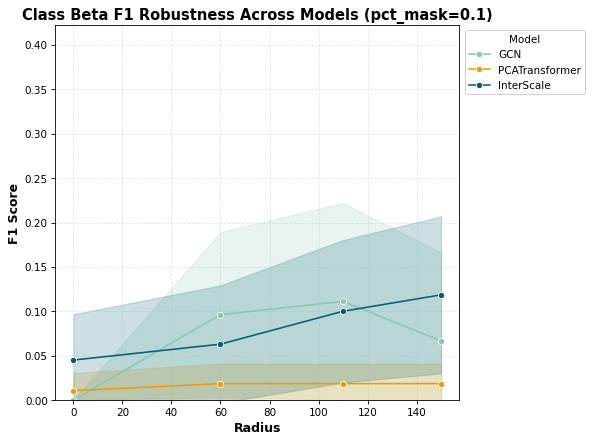


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.096296 0.092962        5
           GCN     110 0.111111 0.111111        5
           GCN     150 0.066667 0.099381        5
    InterScale       0 0.045051 0.051604        5
    InterScale      60 0.062963 0.066254        5
    InterScale     110 0.100000 0.080294        5
    InterScale     150 0.118519 0.088425        5
PCATransformer       0 0.010506 0.019943        5
PCATransformer      60 0.018533 0.022611        5
PCATransformer     110 0.018533 0.022611        5
PCATransformer     150 0.018533 0.022611        5


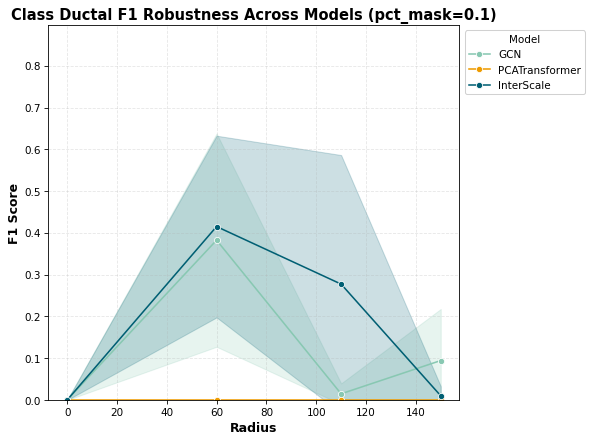


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.382661 0.255139        5
           GCN     110 0.014900 0.024888        5
           GCN     150 0.094515 0.123389        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.415257 0.217409        5
    InterScale     110 0.277471 0.308917        5
    InterScale     150 0.010185 0.022775        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


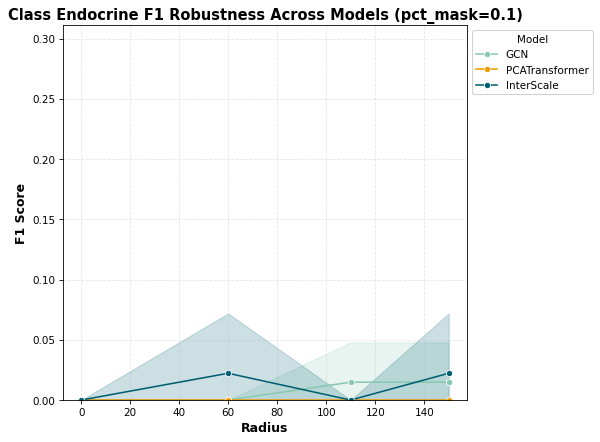


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.000000 0.000000        5
           GCN     110 0.014815 0.033127        5
           GCN     150 0.014815 0.033127        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.022222 0.049690        5
    InterScale     110 0.000000 0.000000        5
    InterScale     150 0.022222 0.049690        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


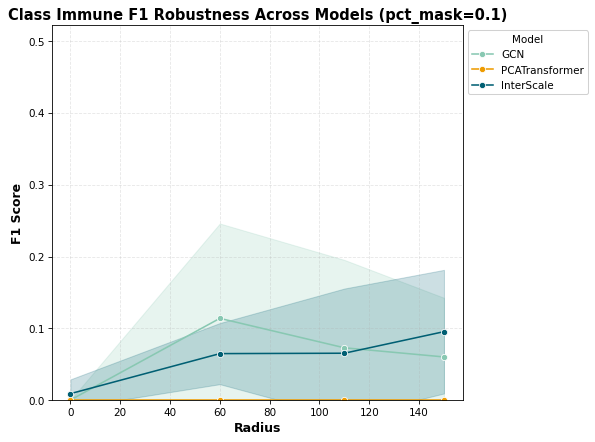


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.113827 0.132129        5
           GCN     110 0.072804 0.122439        5
           GCN     150 0.060056 0.082371        5
    InterScale       0 0.008889 0.019876        5
    InterScale      60 0.064691 0.042567        5
    InterScale     110 0.065238 0.090117        5
    InterScale     150 0.095280 0.086093        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


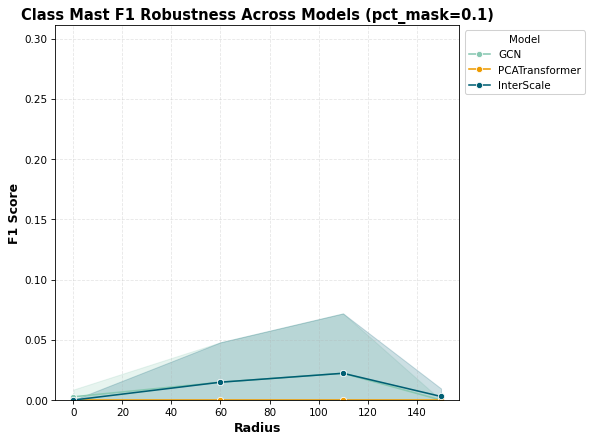


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.002694 0.006023        5
           GCN      60 0.014815 0.033127        5
           GCN     110 0.022222 0.049690        5
           GCN     150 0.000000 0.000000        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.014815 0.033127        5
    InterScale     110 0.022222 0.049690        5
    InterScale     150 0.002963 0.006625        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


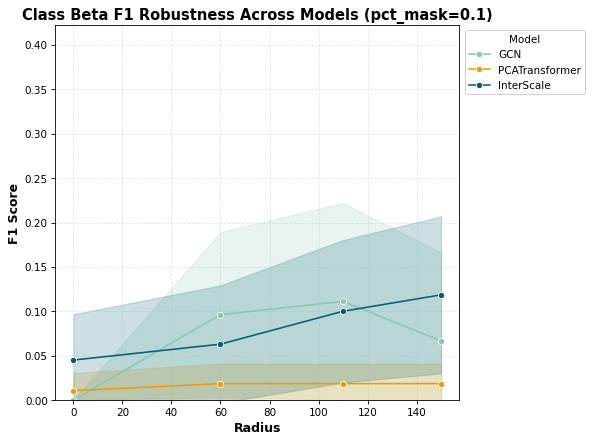


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.096296 0.092962        5
           GCN     110 0.111111 0.111111        5
           GCN     150 0.066667 0.099381        5
    InterScale       0 0.045051 0.051604        5
    InterScale      60 0.062963 0.066254        5
    InterScale     110 0.100000 0.080294        5
    InterScale     150 0.118519 0.088425        5
PCATransformer       0 0.010506 0.019943        5
PCATransformer      60 0.018533 0.022611        5
PCATransformer     110 0.018533 0.022611        5
PCATransformer     150 0.018533 0.022611        5


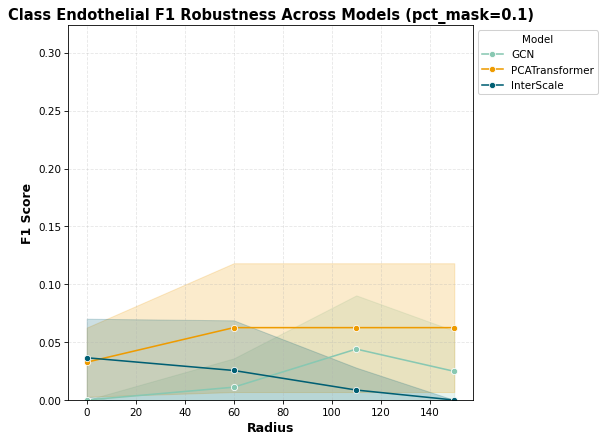


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.011111 0.024845        5
           GCN     110 0.044052 0.046372        5
           GCN     150 0.024804 0.035019        5
    InterScale       0 0.036552 0.033729        5
    InterScale      60 0.025556 0.043319        5
    InterScale     110 0.008642 0.019324        5
    InterScale     150 0.000000 0.000000        5
PCATransformer       0 0.032711 0.029888        5
PCATransformer      60 0.062576 0.055645        5
PCATransformer     110 0.062576 0.055645        5
PCATransformer     150 0.062576 0.055645        5


In [43]:
for class_id in CLASSES: 
    fig, ax, stats = plot_class_f1_robustness(
        wandb_evals,
        class_idx=class_id,
        pct_mask_nodes=0.1,
        BASE_DIR_REPO=BASE_DIR_REPO, 
        save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class"
    )

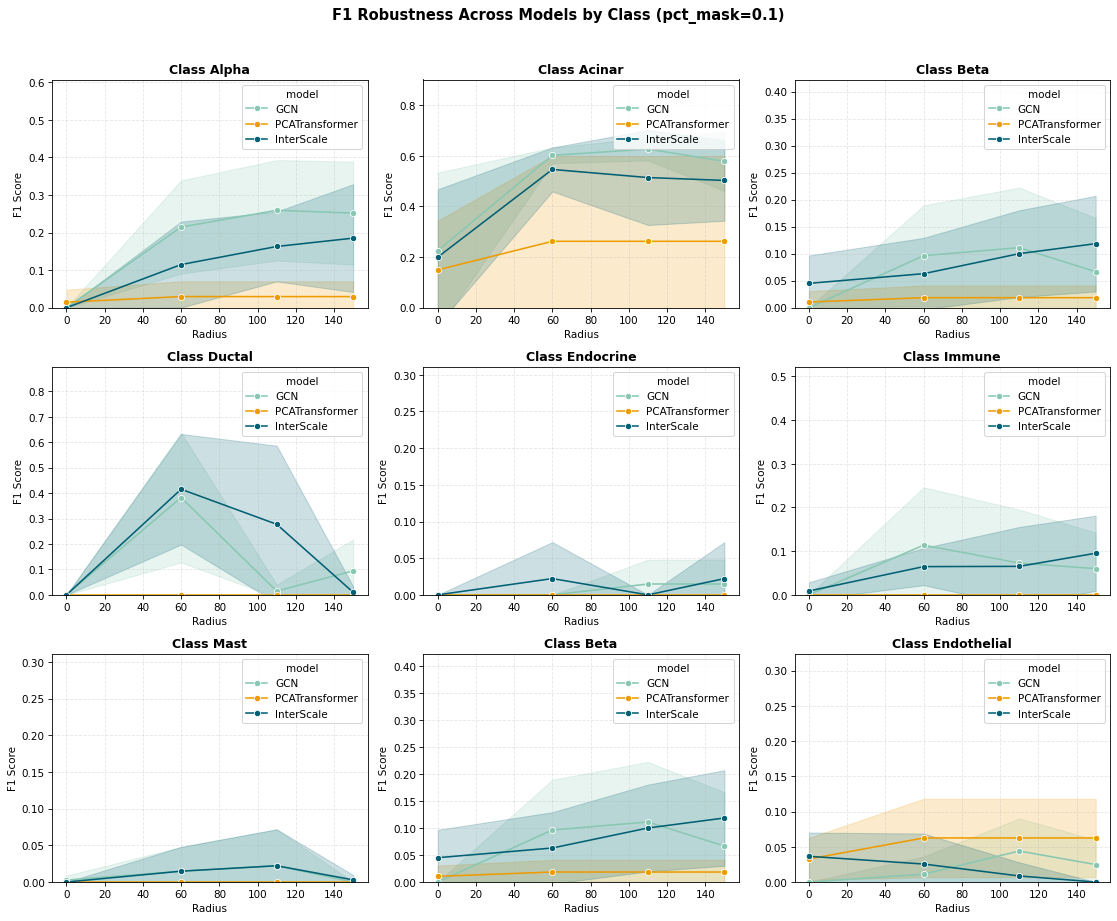


Statistics Summary:
         model  radius     mean      std  n_seeds       class
           GCN       0 0.000000 0.000000        5       Alpha
           GCN      60 0.214815 0.123950        5       Alpha
           GCN     110 0.259259 0.133539        5       Alpha
           GCN     150 0.251852 0.137087        5       Alpha
    InterScale       0 0.000000 0.000000        5       Alpha
    InterScale      60 0.114815 0.114456        5       Alpha
    InterScale     110 0.162963 0.092962        5       Alpha
    InterScale     150 0.185185 0.143444        5       Alpha
PCATransformer       0 0.014815 0.033127        5       Alpha
PCATransformer      60 0.029630 0.040572        5       Alpha
PCATransformer     110 0.029630 0.040572        5       Alpha
PCATransformer     150 0.029630 0.040572        5       Alpha
           GCN       0 0.225348 0.308657        5      Acinar
           GCN      60 0.602019 0.030702        5      Acinar
           GCN     110 0.626900 0.044740        5

In [50]:
fig, ax, stats = plot_class_f1_robustness(
        wandb_evals,
        class_indices=CLASSES,
        pct_mask_nodes=0.1,
        BASE_DIR_REPO=BASE_DIR_REPO, 
        save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class",
        n_cols = 3)